# BiGRU + Dense — Baseline & GWO Optimization
## Architecture: Embedding →  2× BiGRU → Dense → Dropout → Output
## Optimization: Grey Wolf Optimizer (GWO) for hyperparameter tuning

---
### Notebook Sections
1. Environment & Imports  
2. Reproducibility & GPU Setup  
3. Global Configuration  
4. Data Loading  
5. Model Architecture  
6. Utility Functions  
7. Baseline Training  
8. GWO Optimization  
9. Final Model Training (Optimized)  
10. Evaluation & Comparison  
11. Visualization  


## 1. Environment & Imports

In [1]:
# ============================================================
# ENVIRONMENT CONFIGURATION
# Set BEFORE importing TensorFlow to take effect
# ============================================================
import os
import gc

os.environ["TF_CPP_MIN_LOG_LEVEL"]  = "2"     # Suppress TF info/warning logs
os.environ["CUDA_VISIBLE_DEVICES"]  = "0"   # Multi-GPU: change to "0" for single GPU
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"     # Disable OneDNN for determinism # Disable XLA JIT

# ============================================================
# STANDARD LIBRARY
# ============================================================
import warnings
import random
import time
from datetime import timedelta
from typing import Dict, Tuple, List, Optional

# ============================================================
# SCIENTIFIC COMPUTING
# ============================================================
import numpy as np
import pandas as pd

# ============================================================
# DEEP LEARNING
# ============================================================
import tensorflow as tf
tf.config.optimizer.set_jit(False)   # Keep JIT off for reproducibility

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Conv1D, BatchNormalization, MaxPooling1D,
    GRU, Bidirectional, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model

# ============================================================
# EVALUATION
# ============================================================
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    f1_score, accuracy_score
)

# ============================================================
# VISUALIZATION
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# OPTIMIZATION (GWO via mealpy)
# ============================================================
from mealpy.swarm_based.GWO import OriginalGWO
from mealpy import FloatVar, IntegerVar

# ============================================================
# SUPPRESS IRRELEVANT WARNINGS
# ============================================================
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

print(f"✓ TensorFlow  : {tf.__version__}")
print(f"✓ NumPy       : {np.__version__}")
print(f"✓ Pandas      : {pd.__version__}")
print("✓ All imports successful")


2026-03-25 18:24:26.860470: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-25 18:24:26.860572: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-25 18:24:26.920212: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✓ TensorFlow  : 2.15.0
✓ NumPy       : 1.26.0
✓ Pandas      : 2.3.3
✓ All imports successful


## 2. Reproducibility & GPU Setup

In [2]:
# ============================================================
# SEED CONFIGURATION
# ============================================================
RANDOM_STATE: int = 116


def set_seeds(seed: int = RANDOM_STATE) -> None:
    """Set all random seeds for full reproducibility."""
    os.environ["PYTHONHASHSEED"] = str(seed)  # Python hash randomisation
    random.seed(seed)                          # Python built-in
    np.random.seed(seed)                       # NumPy
    tf.random.set_seed(seed)                   # TensorFlow / Keras


# ============================================================
# GPU CONFIGURATION
# ============================================================
def setup_gpu() -> None:
    """Enable dynamic GPU memory growth to prevent OOM errors."""
    gpus = tf.config.list_physical_devices("GPU")

    if not gpus:
        print("⚠  No GPU detected — training will use CPU (slower).")
        return

    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices("GPU")
        print(f"✓ GPUs available: {len(gpus)} physical | {len(logical_gpus)} logical")
    except RuntimeError as e:
        print(f"⚠  GPU setup error (must be called before any GPU ops): {e}")


# Initialise
set_seeds(RANDOM_STATE)
setup_gpu()


✓ GPUs available: 1 physical | 1 logical


## 3. Global Configuration

In [3]:
# ============================================================
# DATASET PATHS  — update to match your environment
# ============================================================
DATA_PATHS: Dict[str, str] = {
    "train": "/home/gibannn/kuliah/sem3/paper/SMILES2VEC/code/SMILES/train_set_balanced.xlsx",
    "test":  "/home/gibannn/kuliah/sem3/paper/SMILES2VEC/code/SMILES/test_set_balanced.xlsx",
    "val":   "/home/gibannn/kuliah/sem3/paper/SMILES2VEC/code/SMILES/val_set_balanced.xlsx",
}

# ============================================================
# TRAINING HYPERPARAMETERS
# ============================================================
EPOCHS:    int = 100    # Maximum epochs for baseline / final model
PATIENCE:  int = 5      # EarlyStopping patience (val_auc)
BATCH_SIZE: int = 64    # Default batch size

# ============================================================
# BASELINE HYPERPARAMETERS  (used when GWO is NOT run)
# ============================================================
BASELINE_PARAMS: Dict = {
    "learning_rate": 3e-4,
    "batch_size":    64,   # Adjust as needed (e.g., 128 or 256 for larger batches)
    "gru_units":     64,    # First BiGRU layer units  (second = gru_units // 2)
    "dense_units":   64,    # Dense head units
    "dropout":       0.3,   # GRU recurrent dropout
    "dense_dropout": 0.4,   # Dropout before output layer
}

# ============================================================
# GWO CONFIGURATION
# ============================================================
GWO_CONFIG: Dict = {
    "pop_size": 10,   # Wolf pack size
    "epoch":    10,   # Optimization rounds
}

# ============================================================
# OUTPUT DIRECTORIES  (auto-created)
# ============================================================
DIRS: Dict[str, str] = {
    "models":  "./models",
    "results": "./results",
    "plots":   "./plots",
    "gwo":     "./gwo_results",
}

for d in DIRS.values():
    os.makedirs(d, exist_ok=True)

MODEL_NAME = "BiGRU_Dense" # Used as prefix for saved files
DIRS = {
    "models" : "./models",
    "results": "./results",
    "plots"  : "./plots",
    "gwo"    : "./gwo_results",
    "images" : "./images",
}

for d in DIRS.values():
    os.makedirs(d, exist_ok=True)

# Derived save paths
BASELINE_MODEL_PATH  = f"{DIRS['models']}/{MODEL_NAME}_baseline.keras"
OPTIMIZED_MODEL_PATH = f"{DIRS['models']}/{MODEL_NAME}_optimized.keras"
MODEL_ARCHITECTURE   = f"{DIRS['images']}/{MODEL_NAME}_architecture.png"

print("Configuration loaded.")
print(f"  Baseline model will save to : {BASELINE_MODEL_PATH}")
print(f"  Optimized model will save to: {OPTIMIZED_MODEL_PATH}")

Configuration loaded.
  Baseline model will save to : ./models/BiGRU_Dense_baseline.keras
  Optimized model will save to: ./models/BiGRU_Dense_optimized.keras


## 4. Data Loading

In [4]:
# SECTION 4 — DATA LOADING

def load_dataset(path: str, name: str) -> Tuple[np.ndarray, np.ndarray]:
    """Load dataset from Excel file and return features and labels as NumPy arrays."""
    
    df = pd.read_excel(path)

    X = df.drop(columns="labels").apply(pd.to_numeric, errors="coerce").fillna(0)
    y = pd.to_numeric(df["labels"], errors="coerce").fillna(0)

    X = np.asarray(X, dtype=np.int32)
    y = np.asarray(y, dtype=np.int32)

    label_counts = pd.Series(y).value_counts().rename(index={0: "Negative", 1: "Positive"})

    print(f"{name.upper():5s} | samples={X.shape[0]:,}  seq_len={X.shape[1]}  ", end="")
    print(f"dtype: X={X.dtype} y={y.dtype}")
    print(f"       label dist: {label_counts.to_dict()}")

    return X, y



# Load Datasets

print("LOADING DATASETS")


X_train, y_train = load_dataset(DATA_PATHS["train"], "train")
X_val,   y_val   = load_dataset(DATA_PATHS["val"],   "val")
X_test,  y_test  = load_dataset(DATA_PATHS["test"],  "test")


LOADING DATASETS
TRAIN | samples=8,260  seq_len=271  dtype: X=int32 y=int32
       label dist: {'Negative': 4167, 'Positive': 4093}
VAL   | samples=1,806  seq_len=271  dtype: X=int32 y=int32
       label dist: {'Positive': 913, 'Negative': 893}
TEST  | samples=1,833  seq_len=271  dtype: X=int32 y=int32
       label dist: {'Positive': 940, 'Negative': 893}


In [5]:

# Vocabulary Size & Sequence Length

VOCAB_SIZE = int(max(X_train.max(), X_val.max(), X_test.max()))
MAX_LEN    = X_train.shape[1]

print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)
print(f"Training samples  : {X_train.shape[0]:,}")
print(f"Validation samples: {X_val.shape[0]:,}")
print(f"Test samples      : {X_test.shape[0]:,}")
print(f"Vocabulary size   : {VOCAB_SIZE:,}")
print(f"Sequence length   : {MAX_LEN}")
print(f"Positive (train)  : {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"Positive (val)    : {y_val.sum():,}   ({y_val.mean()*100:.1f}%)")
print(f"Positive (test)   : {y_test.sum():,}  ({y_test.mean()*100:.1f}%)")
print("=" * 60)


DATASET STATISTICS
Training samples  : 8,260
Validation samples: 1,806
Test samples      : 1,833
Vocabulary size   : 132
Sequence length   : 271
Positive (train)  : 4,093 (49.6%)
Positive (val)    : 913   (50.6%)
Positive (test)   : 940  (51.3%)


## 5. Model Architecture

In [6]:
# ============================================================
# MODEL BUILDER
# ============================================================
# FIX (merged):  Notebook B's build_model() omitted the Conv1D block
# present in Notebook A. The canonical architecture is restored here
# and made fully parameterisable for GWO compatibility.
# ============================================================

def build_bigru_dense_model(
    vocab_size:    int,
    max_len:       int,
    gru_units:     int   = 64,    # First BiGRU output size (second = gru_units // 2)
    dense_units:   int   = 64,    # Dense head units
    dropout:       float = 0.3,   # GRU recurrent dropout
    dense_dropout: float = 0.4,   # Dropout after dense layer
    seed:          int   = RANDOM_STATE,
) -> Sequential:
    set_seeds(seed)

    model = Sequential([

        # ── Embedding ────────────────────────────────────────────
        Embedding(
            input_dim=vocab_size + 1,
            output_dim=128,
            input_length=max_len,
            mask_zero=False,
        ),

        # ── BiGRU layer 1 (returns full sequence) ─────────────────
        Bidirectional(GRU(gru_units,      return_sequences=True,  dropout=dropout)),

        # ── BiGRU layer 2 (collapses to single vector) ────────────
        Bidirectional(GRU(gru_units // 2, return_sequences=False, dropout=dropout)),

        # ── Dense head ───────────────────────────────────────────
        Dense(dense_units, activation="relu"),
        Dropout(dense_dropout),

        # ── Output ───────────────────────────────────────────────
        Dense(1, activation="sigmoid"),

    ], name=f"{MODEL_NAME}_model")

    return model


# Convenience alias for GWO objective function (keeps naming consistent)
build_model = build_bigru_dense_model


# ── Quick sanity check ────────────────────────────────────────────────────────
_m = build_bigru_dense_model(VOCAB_SIZE, MAX_LEN)
_m.build(input_shape=(None, MAX_LEN))
_m.summary()

# Save architecture diagram
_arch_path = os.path.join(DIRS["plots"], f"{MODEL_NAME}_architecture.png")
plot_model(_m, to_file=_arch_path, show_shapes=True, show_layer_names=True)
print(f"\n✓ Architecture diagram saved → {_arch_path}")
del _m   # free memory; we'll build fresh before training


Model: "BiGRU_Dense_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 271, 128)          17024     
                                                                 
 bidirectional (Bidirection  (None, 271, 128)          74496     
 al)                                                             
                                                                 
 bidirectional_1 (Bidirecti  (None, 64)                31104     
 onal)                                                           
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 1)           

## 6. Utility Functions

In [7]:
class ClassificationMetrics:
    """
    Compute and store standard binary classification metrics.

    Usage
    -----
    cm = ClassificationMetrics(y_true, y_pred)
    print(cm.report())
    """

    def __init__(self, y_true: np.ndarray, y_pred: np.ndarray) -> None:
        self.y_true = y_true.flatten()
        self.y_pred = y_pred.flatten()
        self._cm    = confusion_matrix(self.y_true, self.y_pred)

    def confusion_matrix(self) -> np.ndarray:
        return self._cm

    def tp(self) -> int:
        return int(self._cm[1, 1])

    def tn(self) -> int:
        return int(self._cm[0, 0])

    def fp(self) -> int:
        return int(self._cm[0, 1])

    def fn(self) -> int:
        return int(self._cm[1, 0])

    def precision(self) -> float:
        return float(precision_score(self.y_true, self.y_pred, zero_division=0))

    def recall(self) -> float:
        return float(recall_score(self.y_true, self.y_pred, zero_division=0))

    def f1(self) -> float:
        return float(f1_score(self.y_true, self.y_pred, zero_division=0))

    def accuracy(self) -> float:
        return float(accuracy_score(self.y_true, self.y_pred))

    def as_dict(self) -> Dict:
        return {
            "Accuracy" : self.accuracy(),
            "Precision": self.precision(),
            "Recall"   : self.recall(),
            "F1-Score" : self.f1(),
            "TP": self.tp(), "TN": self.tn(),
            "FP": self.fp(), "FN": self.fn(),
        }

    def report(self, title: str = "Classification Metrics") -> str:
        d = self.as_dict()
        lines = ["=" * 50, title, "=" * 50]
        for k, v in d.items():
            lines.append(f"  {k:<12}: {v:.4f}" if isinstance(v, float) else f"  {k:<12}: {v}")
        lines.append("=" * 50)
        return "".join(lines)



# Utility

def to_numpy(x) -> np.ndarray:
    """Convert pandas DataFrame/Series to numpy array if needed."""    
    return x.values if hasattr(x, "values") else x


print("Helper classes/functions defined.")


Helper classes/functions defined.


## 7. Baseline Training

In [8]:
set_seeds(RANDOM_STATE)
tf.config.optimizer.set_jit(False)   # Disable XLA/JIT (prevents libdevice errors)

print("=" * 60)
print("BASELINE MODEL TRAINING")
print("=" * 60)
print(f"  LR={BASELINE_PARAMS['learning_rate']}  Batch={BASELINE_PARAMS['batch_size']}  ", end="")
print(f"GRU={BASELINE_PARAMS['gru_units']}  Dropout={BASELINE_PARAMS['dropout']}")
print("=" * 60)

# Build 
baseline_model = build_model(
    vocab_size = VOCAB_SIZE,
    max_len    = MAX_LEN,
    gru_units  = BASELINE_PARAMS["gru_units"],
    dropout    = BASELINE_PARAMS["dropout"],
)

# Compile 
loss_fn = tf.keras.losses.BinaryFocalCrossentropy(gamma=2)

baseline_model.compile(
    optimizer  = Adam(learning_rate=BASELINE_PARAMS["learning_rate"]),
    loss       = loss_fn,
    metrics    = ["accuracy", tf.keras.metrics.AUC(name="auc")],
    run_eagerly= False,
)

baseline_model.build(input_shape=(None, MAX_LEN))
baseline_model.summary()

# Callbacks 
baseline_callbacks = [
    EarlyStopping(
        monitor             = "val_auc",
        mode                = "max",
        patience            = PATIENCE,
        restore_best_weights= True,
        verbose             = 1,
    ),
    ModelCheckpoint(
        filepath       = BASELINE_MODEL_PATH,
        monitor        = "val_auc",
        mode           = "max",
        save_best_only = True,
        verbose        = 1,
    ),
]

# Train 
baseline_start = time.time()

baseline_history = baseline_model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = EPOCHS ,
    batch_size      = BASELINE_PARAMS["batch_size"],
    callbacks       = baseline_callbacks,
    verbose         = 2,
)

baseline_time = time.time() - baseline_start

print(f"Baseline training completed in {str(timedelta(seconds=int(baseline_time)))}")
print(f"Best model saved to: {BASELINE_MODEL_PATH}")


BASELINE MODEL TRAINING
  LR=0.0003  Batch=64  GRU=64  Dropout=0.3
Model: "BiGRU_Dense_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 271, 128)          17024     
                                                                 
 bidirectional_2 (Bidirecti  (None, 271, 128)          74496     
 onal)                                                           
                                                                 
 bidirectional_3 (Bidirecti  (None, 64)                31104     
 onal)                                                           
                                                                 
 dense_2 (Dense)             (None, 64)                4160      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                

I0000 00:00:1774437907.782844  258916 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Epoch 1: val_auc improved from -inf to 0.95621, saving model to ./models/BiGRU_Dense_baseline.keras
130/130 - 17s - loss: 0.1144 - accuracy: 0.8069 - auc: 0.8786 - val_loss: 0.0636 - val_accuracy: 0.9064 - val_auc: 0.9562 - 17s/epoch - 129ms/step
Epoch 2/100

Epoch 2: val_auc improved from 0.95621 to 0.95680, saving model to ./models/BiGRU_Dense_baseline.keras
130/130 - 11s - loss: 0.0686 - accuracy: 0.9038 - auc: 0.9404 - val_loss: 0.0580 - val_accuracy: 0.9164 - val_auc: 0.9568 - 11s/epoch - 82ms/step
Epoch 3/100

Epoch 3: val_auc improved from 0.95680 to 0.95694, saving model to ./models/BiGRU_Dense_baseline.keras
130/130 - 11s - loss: 0.0636 - accuracy: 0.9109 - auc: 0.9465 - val_loss: 0.0598 - val_accuracy: 0.9208 - val_auc: 0.9569 - 11s/epoch - 84ms/step
Epoch 4/100

Epoch 4: val_auc did not improve from 0.95694
130/130 - 11s - loss: 0.0673 - accuracy: 0.9029 - auc: 0.9414 - val_loss: 0.0579 - val_accuracy: 0.9164 - val_auc: 0.9548 - 11s/epoch - 85ms/step
Epoch 5/100

Epoch 5: v

## 8. GWO Hyperparameter Optimization

In [9]:
# ============================================================
# HYPERPARAMETER SEARCH SPACE  (mealpy 3.0+ variable types)
# ============================================================
# Extend or narrow these bounds to control the GWO search.
# ============================================================

SEARCH_SPACE: Dict = {
    "learning_rate": (1e-5, 1e-2),
    "batch_size":    (32,   64),  # Adjust upper bound as needed (e.g., 256 for larger batches)
    "gru_units":     (32,   128),
    "dense_units":   (32,   128),
    "dropout":       (0.1,  0.5),
}

# mealpy bound descriptors — order must match objective_function extraction
gwo_bounds = [
    FloatVar(lb=SEARCH_SPACE["learning_rate"][0], ub=SEARCH_SPACE["learning_rate"][1], name="learning_rate"),
    IntegerVar(lb=SEARCH_SPACE["batch_size"][0],  ub=SEARCH_SPACE["batch_size"][1],    name="batch_size"),
    IntegerVar(lb=SEARCH_SPACE["gru_units"][0],   ub=SEARCH_SPACE["gru_units"][1],     name="gru_units"),
    IntegerVar(lb=SEARCH_SPACE["dense_units"][0], ub=SEARCH_SPACE["dense_units"][1],   name="dense_units"),
    FloatVar(lb=SEARCH_SPACE["dropout"][0],       ub=SEARCH_SPACE["dropout"][1],       name="dropout"),
]

print("✓ GWO search space:")
for k, (lo, hi) in SEARCH_SPACE.items():
    print(f"  {k:<16}: [{lo}, {hi}]")


✓ GWO search space:
  learning_rate   : [1e-05, 0.01]
  batch_size      : [32, 64]
  gru_units       : [32, 128]
  dense_units     : [32, 128]
  dropout         : [0.1, 0.5]


In [10]:
# ============================================================
# GWO OBJECTIVE FUNCTION
# ============================================================
# IMPROVEMENT: clear_session() is called at the start of each
# evaluation to free GPU memory and avoid graph accumulation over
# many evaluations.  dense_dropout is kept fixed at the baseline
# value (0.4) since it is less sensitive than recurrent dropout.
# ============================================================

_iter_count    = 0
_best_f1_gwo   = 0.0
_gwo_log: List = []


def objective_function(solution: np.ndarray) -> float:
    """
    Evaluate one candidate hyperparameter set.

    Args
    ----
    solution : [learning_rate, batch_size, gru_units, dense_units, dropout]

    Returns
    -------
    float  —  Negative F1-score on the validation set (minimisation target).
    """
    global _iter_count, _best_f1_gwo

    _iter_count += 1

    # ── Extract hyperparameters ───────────────────────────────────────────────
    lr          = float(solution[0])
    batch_size  = int(round(float(solution[1])))
    gru_units   = int(round(float(solution[2])))
    dense_units = int(round(float(solution[3])))
    dropout     = float(solution[4])

    # Clamp to valid ranges (safeguard against floating-point edge cases)
    batch_size  = max(32,  min(batch_size,  512))
    gru_units   = max(16,  min(gru_units,   128))
    dense_units = max(16,  min(dense_units, 128))
    dropout     = max(0.0, min(dropout,     0.6))

    print(f"\n[GWO iter {_iter_count:03d}]  "
          f"lr={lr:.2e}  batch={batch_size}  "
          f"gru={gru_units}  dense={dense_units}  "
          f"dropout={dropout:.3f}")

    try:
        # Clear session to prevent GPU memory accumulation
        tf.keras.backend.clear_session()
        set_seeds(RANDOM_STATE)

        model = build_bigru_dense_model(
            vocab_size    = VOCAB_SIZE,
            max_len       = MAX_LEN,
            gru_units     = gru_units,
            dense_units   = dense_units,
            dropout       = dropout,
            dense_dropout = BASELINE_PARAMS["dense_dropout"],  # kept fixed
        )

        model.compile(
            optimizer = Adam(learning_rate=lr),
            loss      = tf.keras.losses.BinaryFocalCrossentropy(gamma=2),
            metrics   = ["accuracy", tf.keras.metrics.AUC(name="auc")],
        )

        # Reduced-epoch training for efficiency during search
        history = model.fit(
            X_train, y_train,
            validation_data = (X_val, y_val),
            epochs          = 30,
            batch_size      = batch_size,
            callbacks       = [
                EarlyStopping(monitor="val_auc", mode="max",
                              patience=3, restore_best_weights=True, verbose=0)
            ],
            verbose = 0,
        )

        y_pred = (model.predict(X_val, verbose=0) > 0.5).astype(int).flatten()
        f1  = float(f1_score(y_val, y_pred,    zero_division=0))
        acc = float(accuracy_score(y_val, y_pred))
        eps = len(history.history["loss"])

        if f1 > _best_f1_gwo:
            _best_f1_gwo = f1
            print(f"  → NEW BEST  F1={f1:.4f}  Acc={acc:.4f}  (ep={eps})")
        else:
            print(f"  → F1={f1:.4f}  Acc={acc:.4f}  (ep={eps})")

        _gwo_log.append({
            "iteration":    _iter_count,
            "learning_rate": lr,
            "batch_size":   batch_size,
            "gru_units":    gru_units,
            "dense_units":  dense_units,
            "dropout":      dropout,
            "f1_score":     f1,
            "accuracy":     acc,
            "epochs":       eps,
        })

        return -f1   # mealpy minimises

    except Exception as exc:
        print(f"  ✗ Evaluation failed: {exc}")
        _gwo_log.append({
            "iteration": _iter_count,
            "learning_rate": lr, "batch_size": batch_size,
            "gru_units": gru_units, "dense_units": dense_units,
            "dropout": dropout,
            "f1_score": 0.0, "accuracy": 0.0, "epochs": eps,
            "train_loss": float(history.history["loss"][-1]),
        })
        return 0.0


print("✓ GWO objective function defined")


✓ GWO objective function defined


In [11]:
# ============================================================
# RUN GWO OPTIMISATION
# ============================================================

print("\n" + "=" * 60)
print("STARTING GWO OPTIMISATION")
print("=" * 60)
print(f"  Population size    : {GWO_CONFIG['pop_size']}")
print(f"  Epochs             : {GWO_CONFIG['epoch']}")
print(f"  Total evaluations  : {GWO_CONFIG['pop_size'] * GWO_CONFIG['epoch']}")
print("=" * 60 + "\n")

# Reset counters before each run (allows re-running this cell cleanly)
_iter_count  = 0
_best_f1_gwo = 0.0
_gwo_log     = []

gwo_optimizer = OriginalGWO(
    epoch    = GWO_CONFIG["epoch"],
    pop_size = GWO_CONFIG["pop_size"],
)

_gwo_start = time.time()
g_best = gwo_optimizer.solve({
    "obj_func": objective_function,
    "bounds":   gwo_bounds,
    "minmax":   "min",
})
gwo_time = time.time() - _gwo_start

best_solution = g_best.solution
best_fitness  = g_best.target.fitness

print("\n" + "=" * 60)
print("GWO OPTIMISATION COMPLETE")
print("=" * 60)
print(f"  Total time  : {str(timedelta(seconds=int(gwo_time)))}")
print(f"  Best val F1 : {-best_fitness:.4f}")
print("=" * 60)

# ── Save optimisation log ─────────────────────────────────────────────────────
gwo_log_df = pd.DataFrame(_gwo_log)
_log_path  = os.path.join(DIRS["gwo"], f"{MODEL_NAME}_gwo_log.csv")
gwo_log_df.to_csv(_log_path, index=False)
print(f"✓ Optimisation log → {_log_path}")


2026/03/25 06:31:14 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=10, pop_size=10)



STARTING GWO OPTIMISATION
  Population size    : 10
  Epochs             : 10
  Total evaluations  : 100


[GWO iter 001]  lr=6.02e-03  batch=48  gru=43  dense=34  dropout=0.486
  → NEW BEST  F1=0.9285  Acc=0.9324  (ep=14)

[GWO iter 002]  lr=2.10e-03  batch=61  gru=118  dense=90  dropout=0.387
  → NEW BEST  F1=0.9394  Acc=0.9413  (ep=26)

[GWO iter 003]  lr=2.44e-03  batch=32  gru=58  dense=102  dropout=0.107
  → F1=0.9243  Acc=0.9286  (ep=8)

[GWO iter 004]  lr=6.13e-03  batch=32  gru=125  dense=87  dropout=0.226
  → F1=0.9224  Acc=0.9269  (ep=5)

[GWO iter 005]  lr=2.90e-03  batch=58  gru=99  dense=78  dropout=0.186
  → F1=0.9309  Acc=0.9341  (ep=15)

[GWO iter 006]  lr=9.75e-03  batch=49  gru=66  dense=106  dropout=0.226
  → F1=0.9176  Acc=0.9230  (ep=7)

[GWO iter 007]  lr=1.72e-03  batch=53  gru=73  dense=73  dropout=0.420
  → F1=0.9253  Acc=0.9297  (ep=16)

[GWO iter 008]  lr=8.86e-04  batch=46  gru=59  dense=95  dropout=0.499
  → F1=0.9218  Acc=0.9247  (ep=14)

[GWO iter 009] 

2026/03/25 07:27:02 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: -0.9393592677345538, Global best: -0.9393592677345538, Runtime: 1842.03885 seconds


  → F1=0.9270  Acc=0.9297  (ep=15)

[GWO iter 021]  lr=2.96e-03  batch=36  gru=87  dense=59  dropout=0.168
  → F1=0.9369  Acc=0.9380  (ep=15)

[GWO iter 022]  lr=1.02e-03  batch=42  gru=51  dense=83  dropout=0.486
  → F1=0.9261  Acc=0.9302  (ep=21)

[GWO iter 023]  lr=1.09e-03  batch=36  gru=93  dense=87  dropout=0.480
  → F1=0.9310  Acc=0.9336  (ep=23)

[GWO iter 024]  lr=2.45e-03  batch=59  gru=128  dense=53  dropout=0.500
  → F1=0.9246  Acc=0.9291  (ep=9)

[GWO iter 025]  lr=2.64e-03  batch=32  gru=70  dense=32  dropout=0.500
  → F1=0.9237  Acc=0.9280  (ep=10)

[GWO iter 026]  lr=2.61e-03  batch=34  gru=70  dense=55  dropout=0.394
  → F1=0.9389  Acc=0.9408  (ep=22)

[GWO iter 027]  lr=3.71e-03  batch=44  gru=71  dense=57  dropout=0.365
  → F1=0.9323  Acc=0.9352  (ep=22)

[GWO iter 028]  lr=1.00e-05  batch=64  gru=128  dense=49  dropout=0.319
  → F1=0.9063  Acc=0.9114  (ep=30)

[GWO iter 029]  lr=9.90e-04  batch=60  gru=109  dense=67  dropout=0.500
  → F1=0.9389  Acc=0.9402  (ep=30)


2026/03/25 08:13:51 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: -0.9395138496325608, Global best: -0.9395138496325608, Runtime: 2809.95432 seconds


...

  → F1=0.9399  Acc=0.9419  (ep=29)

[GWO iter 091]  lr=1.68e-03  batch=50  gru=119  dense=64  dropout=0.384
  → F1=0.9385  Acc=0.9391  (ep=23)

[GWO iter 092]  lr=1.58e-03  batch=46  gru=111  dense=60  dropout=0.389
  → F1=0.9280  Acc=0.9313  (ep=18)

[GWO iter 093]  lr=1.63e-03  batch=48  gru=110  dense=63  dropout=0.387
  → F1=0.9399  Acc=0.9408  (ep=30)

[GWO iter 094]  lr=1.65e-03  batch=49  gru=111  dense=63  dropout=0.391
  → F1=0.9223  Acc=0.9258  (ep=9)

[GWO iter 095]  lr=1.65e-03  batch=49  gru=115  dense=61  dropout=0.367
  → F1=0.9417  Acc=0.9430  (ep=30)

[GWO iter 096]  lr=1.65e-03  batch=51  gru=120  dense=59  dropout=0.418
  → F1=0.9441  Acc=0.9452  (ep=30)

[GWO iter 097]  lr=1.62e-03  batch=47  gru=106  dense=64  dropout=0.390
  → F1=0.9311  Acc=0.9341  (ep=23)

[GWO iter 098]  lr=1.73e-03  batch=44  gru=120  dense=60  dropout=0.394
  → F1=0.9364  Acc=0.9385  (ep=18)

[GWO iter 099]  lr=1.70e-03  batch=48  gru=117  dense=63  dropout=0.411
  → F1=0.9352  Acc=0.9369  (e

2026/03/26 12:55:50 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 9, Current best: -0.9474272930648769, Global best: -0.9474272930648769, Runtime: 2811.54957 seconds


  → F1=0.9244  Acc=0.9286  (ep=14)

[GWO iter 101]  lr=1.64e-03  batch=48  gru=115  dense=61  dropout=0.384
  → F1=0.9317  Acc=0.9341  (ep=21)

[GWO iter 102]  lr=1.64e-03  batch=48  gru=115  dense=61  dropout=0.384
  → F1=0.9394  Acc=0.9408  (ep=30)

[GWO iter 103]  lr=1.64e-03  batch=48  gru=115  dense=61  dropout=0.384
  → F1=0.9440  Acc=0.9452  (ep=30)

[GWO iter 104]  lr=1.64e-03  batch=48  gru=115  dense=61  dropout=0.384
  → F1=0.9445  Acc=0.9452  (ep=27)

[GWO iter 105]  lr=1.64e-03  batch=48  gru=115  dense=61  dropout=0.384
  → F1=0.9246  Acc=0.9286  (ep=12)

[GWO iter 106]  lr=1.64e-03  batch=48  gru=115  dense=61  dropout=0.384
  → F1=0.9223  Acc=0.9269  (ep=9)

[GWO iter 107]  lr=1.64e-03  batch=48  gru=115  dense=61  dropout=0.384
  → F1=0.9206  Acc=0.9241  (ep=9)

[GWO iter 108]  lr=1.64e-03  batch=48  gru=115  dense=61  dropout=0.384
  → F1=0.9392  Acc=0.9402  (ep=24)

[GWO iter 109]  lr=1.64e-03  batch=48  gru=115  dense=61  dropout=0.384
  → F1=0.9277  Acc=0.9313  (ep

2026/03/26 01:33:59 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 10, Current best: -0.9474272930648769, Global best: -0.9474272930648769, Runtime: 2289.46519 seconds


  → F1=0.9259  Acc=0.9297  (ep=10)

GWO OPTIMISATION COMPLETE
  Total time  : 7:02:45
  Best val F1 : 0.9474
✓ Optimisation log → ./gwo_results/BiGRU_Dense_gwo_log.csv


In [12]:
# ============================================================
# EXTRACT BEST HYPERPARAMETERS
# ============================================================

best_params: Dict = {
    "learning_rate": float(best_solution[0]),
    "batch_size":    int(round(float(best_solution[1]))),
    "gru_units":     int(round(float(best_solution[2]))),
    "dense_units":   int(round(float(best_solution[3]))),
    "dropout":       float(best_solution[4]),
    "dense_dropout": BASELINE_PARAMS["dense_dropout"],   # inherited (not tuned)
}

print("\n" + "=" * 60)
print("BEST HYPERPARAMETERS FOUND BY GWO")
print("=" * 60)
for k, v in best_params.items():
    fmt = f"{v:.6f}" if isinstance(v, float) else str(v)
    print(f"  {k:<16}: {fmt}")
print("=" * 60)

# Persist
_bp_path = os.path.join(DIRS["gwo"], f"{MODEL_NAME}_best_params.csv")
pd.DataFrame([best_params]).to_csv(_bp_path, index=False)
print(f"\n✓ Best parameters saved → {_bp_path}")



BEST HYPERPARAMETERS FOUND BY GWO
  learning_rate   : 0.001769
  batch_size      : 50
  gru_units       : 104
  dense_units     : 64
  dropout         : 0.352501
  dense_dropout   : 0.400000

✓ Best parameters saved → ./gwo_results/BiGRU_Dense_best_params.csv


## 9. Final Model Training (Optimized Hyperparameters)

In [13]:

print("=" * 60)
print("FINAL MODEL TRAINING  (GWO-Optimised Hyperparameters)")
print("=" * 60)
print("Hyperparameters:", best_params)
print()

tf.keras.backend.clear_session()
set_seeds(RANDOM_STATE)

optimized_model = build_bigru_dense_model(
    vocab_size    = VOCAB_SIZE,
    max_len       = MAX_LEN,
    gru_units     = best_params["gru_units"],
    dense_units   = best_params["dense_units"],
    dropout       = best_params["dropout"],
    dense_dropout = best_params["dense_dropout"],
)

optimized_model.compile(
    optimizer = Adam(learning_rate=best_params["learning_rate"]),
    loss      = tf.keras.losses.BinaryFocalCrossentropy(gamma=2),
    metrics   = ["accuracy", tf.keras.metrics.AUC(name="auc")],
)

optimized_model.summary()

optimized_save_path = os.path.join(DIRS["models"], f"{MODEL_NAME}_optimized_best.keras")

opt_start = time.time()
optimized_history = optimized_model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = EPOCHS,
    batch_size      = best_params["batch_size"],
    callbacks       = [
        EarlyStopping(monitor="val_auc", mode="max",
                      patience=PATIENCE, restore_best_weights=True, verbose=1),
        ModelCheckpoint(filepath=optimized_save_path, monitor="val_auc",
                        mode="max", save_best_only=True, verbose=1),
    ],
    verbose         = 2,
)

optimized_time = time.time() - opt_start

print(f"Optimized training completed in {str(timedelta(seconds=int(optimized_time)))}")
print(f"Best model saved to: {OPTIMIZED_MODEL_PATH}")


FINAL MODEL TRAINING  (GWO-Optimised Hyperparameters)
Hyperparameters: {'learning_rate': 0.001768637497672339, 'batch_size': 50, 'gru_units': 104, 'dense_units': 64, 'dropout': 0.3525006802552025, 'dense_dropout': 0.4}

Model: "BiGRU_Dense_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 271, 128)          17024     
                                                                 
 bidirectional (Bidirection  (None, 271, 208)          146016    
 al)                                                             
                                                                 
 bidirectional_1 (Bidirecti  (None, 104)               81744     
 onal)                                                           
                                                                 
 dense (Dense)               (None, 64)                6720      
                           

## 10. Evaluation & Comparison

In [14]:

# Evaluate Both Models on Validation & Test Sets


def evaluate_model(model, X, y, label="") -> ClassificationMetrics:
    """Predict and return ClassificationMetrics for a given split."""    
    y_pred = (model.predict(X, verbose=0) > 0.5).astype(int).flatten()
    return ClassificationMetrics(y, y_pred)


# Baseline
baseline_val_metrics  = evaluate_model(baseline_model,  X_val,  y_val,  "Baseline Val")
baseline_test_metrics = evaluate_model(baseline_model,  X_test, y_test, "Baseline Test")

# Optimized
optimized_val_metrics  = evaluate_model(optimized_model, X_val,  y_val,  "Optimized Val")
optimized_test_metrics = evaluate_model(optimized_model, X_test, y_test, "Optimized Test")

# Print reports 
print(baseline_test_metrics.report("BASELINE — Test Set"))
print()
print(optimized_test_metrics.report("GWO-OPTIMIZED — Test Set"))


==================================================BASELINE — Test Set==================================================  Accuracy    : 0.9329  Precision   : 0.9940  Recall      : 0.8745  F1-Score    : 0.9304  TP          : 822  TN          : 888  FP          : 5  FN          : 118==================================================

==================================================GWO-OPTIMIZED — Test Set==================================================  Accuracy    : 0.9514  Precision   : 0.9830  Recall      : 0.9213  F1-Score    : 0.9511  TP          : 866  TN          : 878  FP          : 15  FN          : 74==================================================


## 11. Visualization

In [15]:

# Side-by-Side Comparison DataFrame


def metrics_row(label, params, cm: ClassificationMetrics, train_time_s: float) -> Dict:
    d = cm.as_dict()
    return {
        "Model"         : label,
        "LR"            : params["learning_rate"],
        "Batch"         : params["batch_size"],
        "GRU_Units"     : params["gru_units"],
        "Dropout"       : params["dropout"],
        "Accuracy"      : d["Accuracy"],
        "Precision"     : d["Precision"],
        "Recall"        : d["Recall"],
        "F1-Score"      : d["F1-Score"],
        "TP"            : d["TP"],
        "TN"            : d["TN"],
        "FP"            : d["FP"],
        "FN"            : d["FN"],
        "Training_Time" : str(timedelta(seconds=int(train_time_s))),
    }


comparison_df = pd.DataFrame([
    metrics_row("Baseline",      BASELINE_PARAMS, baseline_test_metrics,  baseline_time),
    metrics_row("GWO-Optimized", best_params,     optimized_test_metrics, optimized_time),
])

f1_improvement  = (optimized_test_metrics.f1()  - baseline_test_metrics.f1())  / max(baseline_test_metrics.f1(),  1e-9) * 100
acc_improvement = (optimized_test_metrics.accuracy() - baseline_test_metrics.accuracy()) / max(baseline_test_metrics.accuracy(), 1e-9) * 100

print("" + "=" * 90)
print("BASELINE vs GWO-OPTIMIZED — TEST SET COMPARISON")
print("=" * 90)
print(comparison_df.to_string(index=False))
print("" + "=" * 90)
print(f"  F1 improvement  : {f1_improvement:+.2f}%")
print(f"  Acc improvement : {acc_improvement:+.2f}%")
print("=" * 90)

# Save comparison CSV
comp_path = f"{DIRS['results']}/{MODEL_NAME}_comparison.csv"
comparison_df.to_csv(comp_path, index=False)
print(f"Comparison saved to: {comp_path}")


BASELINE vs GWO-OPTIMIZED — TEST SET COMPARISON
        Model       LR  Batch  GRU_Units  Dropout  Accuracy  Precision   Recall  F1-Score  TP  TN  FP  FN Training_Time
     Baseline 0.000300     64         64 0.300000  0.932897   0.993954 0.874468  0.930390 822 888   5 118       0:06:10
GWO-Optimized 0.001769     50        104 0.352501  0.951446   0.982974 0.921277  0.951126 866 878  15  74       0:07:41
  F1 improvement  : +2.23%
  Acc improvement : +1.99%
Comparison saved to: ./results/BiGRU_Dense_comparison.csv


In [16]:

# Save Training History CSVs


def save_history_csv(history, name: str) -> str:
    epochs = len(history.history["loss"])
    df = pd.DataFrame({
        "epoch"         : range(1, epochs + 1),
        "train_loss"    : history.history["loss"],
        "val_loss"      : history.history["val_loss"],
        "train_accuracy": history.history["accuracy"],
        "val_accuracy"  : history.history["val_accuracy"],
        "train_auc"     : history.history["auc"],
        "val_auc"       : history.history["val_auc"],
    })
    path = f"{DIRS['results']}/{name}_history.csv"
    df.to_csv(path, index=False)
    print(f"  Saved: {path}")
    return path


print("Saving training histories...")
save_history_csv(baseline_history,   f"{MODEL_NAME}_baseline")
save_history_csv(optimized_history,  f"{MODEL_NAME}_optimized")


Saving training histories...
  Saved: ./results/BiGRU_Dense_baseline_history.csv
  Saved: ./results/BiGRU_Dense_optimized_history.csv


'./results/BiGRU_Dense_optimized_history.csv'

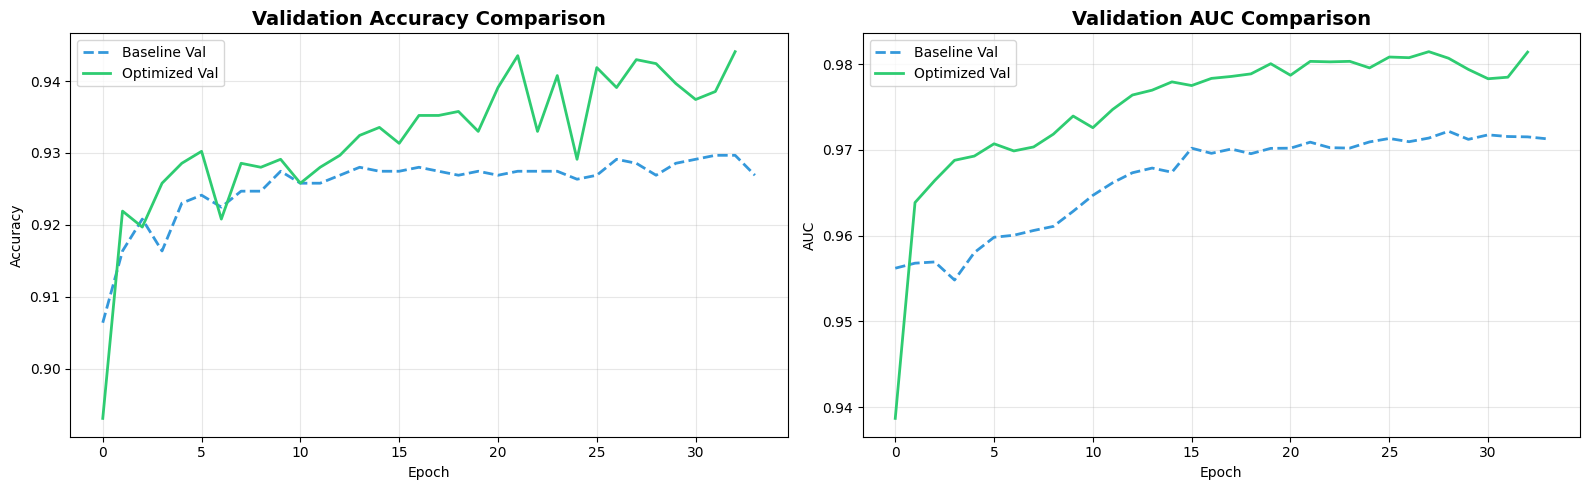

Saved: ./plots/BiGRU_Dense_training_comparison.png


In [17]:

# Training Curves — Baseline vs Optimized


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, title in zip(
    axes,
    [("accuracy", "val_accuracy"), ("auc", "val_auc")],
    ["Accuracy", "AUC"],
):
    train_key, val_key = metric
    ax.plot(baseline_history.history[val_key],
            label="Baseline Val",    linewidth=2, linestyle="--", color="#3498db")
    ax.plot(optimized_history.history[val_key],
            label="Optimized Val",   linewidth=2, color="#2ecc71")
    ax.set_title(f"Validation {title} Comparison", fontsize=14, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
train_cmp_path = f"{DIRS['plots']}/{MODEL_NAME}_training_comparison.png"
plt.savefig(train_cmp_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {train_cmp_path}")


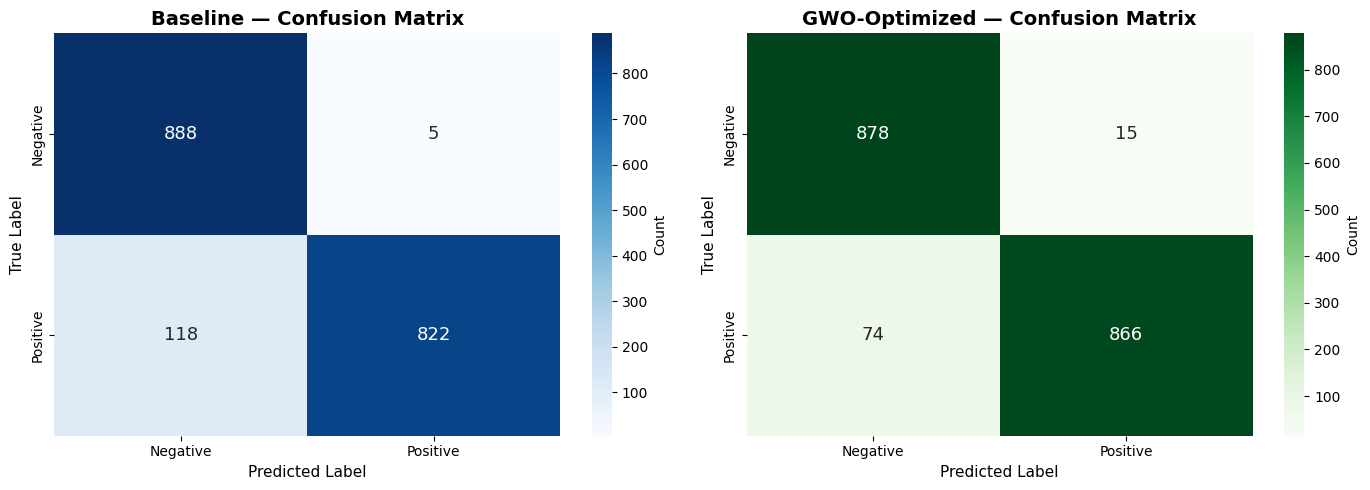

Saved: ./plots/BiGRU_Dense_confusion_comparison.png


In [18]:

# Confusion Matrices — Baseline vs Optimized (Test Set)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm_obj, title, cmap in zip(
    axes,
    [baseline_test_metrics, optimized_test_metrics],
    ["Baseline", "GWO-Optimized"],
    ["Blues", "Greens"],
):
    sns.heatmap(
        cm_obj.confusion_matrix(), annot=True, fmt="d",
        cmap=cmap, ax=ax,
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"],
        cbar_kws={"label": "Count"}, annot_kws={"size": 13},
    )
    ax.set_title(f"{title} — Confusion Matrix", fontsize=14, fontweight="bold")
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)

plt.tight_layout()
cm_path = f"{DIRS['plots']}/{MODEL_NAME}_confusion_comparison.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {cm_path}")


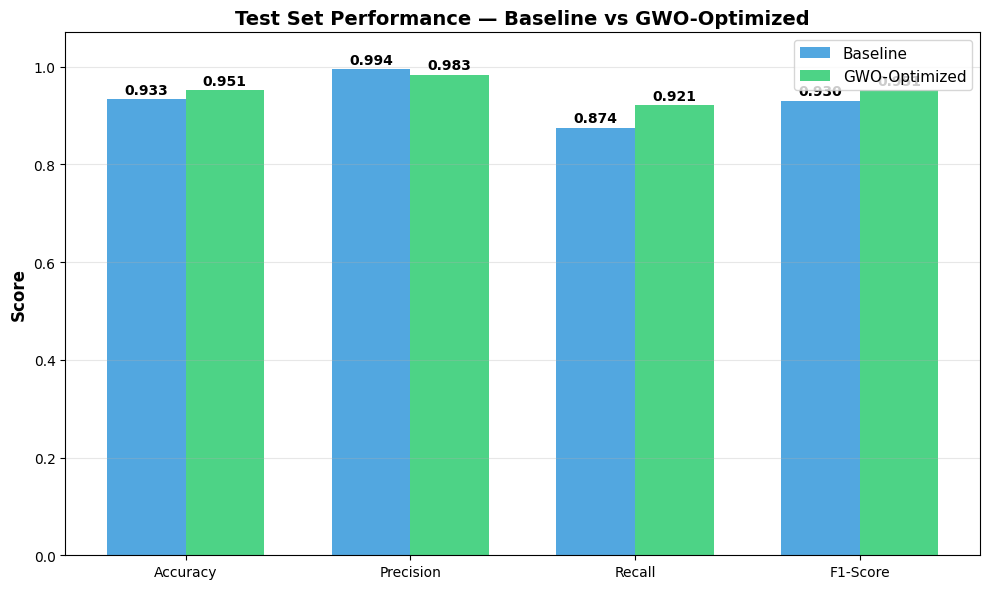

Saved: ./plots/BiGRU_Dense_metrics_comparison.png


In [19]:

# Metrics Bar Chart — Test Set


metric_names  = ["Accuracy", "Precision", "Recall", "F1-Score"]
base_values   = [baseline_test_metrics.accuracy(), baseline_test_metrics.precision(),
                  baseline_test_metrics.recall(),   baseline_test_metrics.f1()]
opt_values    = [optimized_test_metrics.accuracy(), optimized_test_metrics.precision(),
                  optimized_test_metrics.recall(),   optimized_test_metrics.f1()]

x     = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, base_values, width, label="Baseline",      color="#3498db", alpha=0.85)
bars2 = ax.bar(x + width/2, opt_values,  width, label="GWO-Optimized", color="#2ecc71", alpha=0.85)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.005,
                f"{h:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("Score", fontsize=12, fontweight="bold")
ax.set_title("Test Set Performance — Baseline vs GWO-Optimized", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim([0, 1.07])
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
bar_path = f"{DIRS['plots']}/{MODEL_NAME}_metrics_comparison.png"
plt.savefig(bar_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {bar_path}")


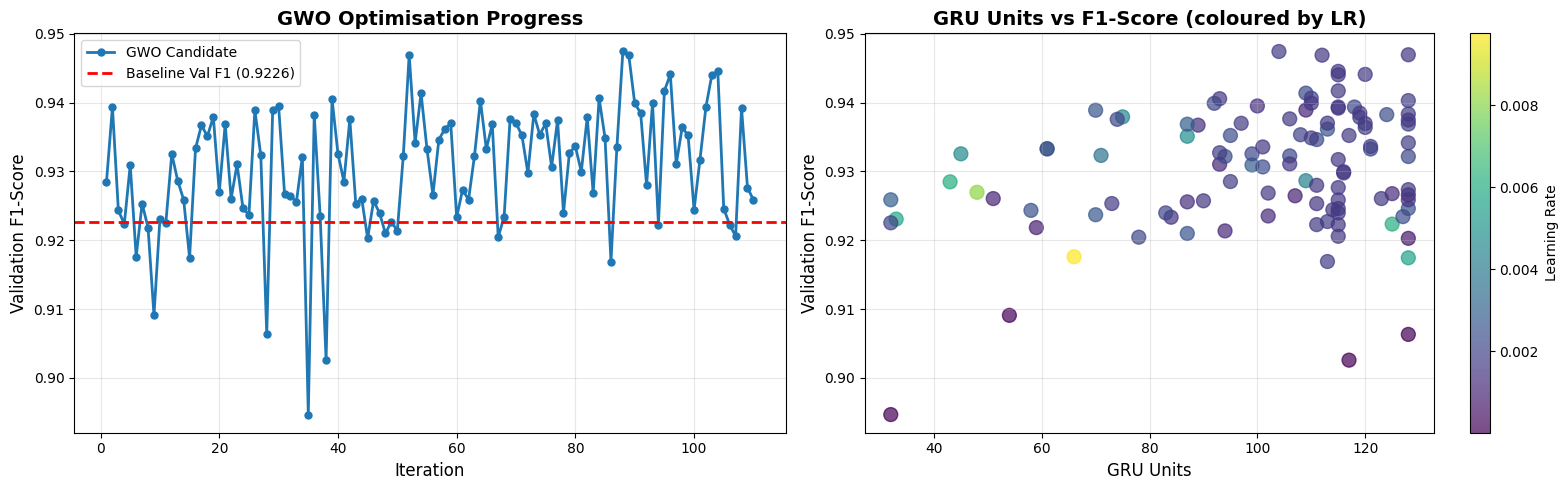

Saved: ./plots/BiGRU_Dense_gwo_progress.png


In [21]:

# GWO Optimisation Progress


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# F1 over iterations
axes[0].plot(gwo_log_df["iteration"], gwo_log_df["f1_score"],
             marker="o", linewidth=2, markersize=5, label="GWO Candidate")
axes[0].axhline(y=baseline_val_metrics.f1(), color="r", linestyle="--",
                label=f"Baseline Val F1 ({baseline_val_metrics.f1():.4f})", linewidth=2)
axes[0].set_xlabel("Iteration", fontsize=12)
axes[0].set_ylabel("Validation F1-Score", fontsize=12)
axes[0].set_title("GWO Optimisation Progress", fontsize=14, fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# GRU units vs F1 (coloured by LR)
sc = axes[1].scatter(
    gwo_log_df["gru_units"], gwo_log_df["f1_score"],
    s=100, alpha=0.7, c=gwo_log_df["learning_rate"], cmap="viridis",
)
plt.colorbar(sc, ax=axes[1], label="Learning Rate")
axes[1].set_xlabel("GRU Units", fontsize=12)
axes[1].set_ylabel("Validation F1-Score", fontsize=12)
axes[1].set_title("GRU Units vs F1-Score (coloured by LR)", fontsize=14, fontweight="bold")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
gwo_prog_path = f"{DIRS['plots']}/{MODEL_NAME}_gwo_progress.png"
plt.savefig(gwo_prog_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {gwo_prog_path}")


In [22]:

# Final Summary

print("" + "=" * 70)
print("EXPERIMENT SUMMARY")
print("=" * 70)

print("[Baseline]")
print(f"  Hyperparams : LR={BASELINE_PARAMS['learning_rate']}  Batch={BASELINE_PARAMS['batch_size']}  ", end="")
print(f"GRU={BASELINE_PARAMS['gru_units']}  Drop={BASELINE_PARAMS['dropout']}")
print(f"  Test F1     : {baseline_test_metrics.f1():.4f}")
print(f"  Test Acc    : {baseline_test_metrics.accuracy():.4f}")
print(f"  Saved model : {BASELINE_MODEL_PATH}")
print(f"  Train time  : {str(timedelta(seconds=int(baseline_time)))}")

print("[GWO-Optimized]")
print(f"  Hyperparams : LR={best_params['learning_rate']:.2e}  Batch={best_params['batch_size']}  ", end="")
print(f"GRU={best_params['gru_units']}  Drop={best_params['dropout']:.4f}")
print(f"  Test F1     : {optimized_test_metrics.f1():.4f}")
print(f"  Test Acc    : {optimized_test_metrics.accuracy():.4f}")
print(f"  Saved model : {OPTIMIZED_MODEL_PATH}")
print(f"  Train time  : {str(timedelta(seconds=int(optimized_time)))}")

print(f"[Improvement]")
print(f"  F1  : {f1_improvement:+.2f}%")
print(f"  Acc : {acc_improvement:+.2f}%")
print("=" * 70)


EXPERIMENT SUMMARY
[Baseline]
  Hyperparams : LR=0.0003  Batch=64  GRU=64  Drop=0.3
  Test F1     : 0.9304
  Test Acc    : 0.9329
  Saved model : ./models/BiGRU_Dense_baseline.keras
  Train time  : 0:06:10
[GWO-Optimized]
  Hyperparams : LR=1.77e-03  Batch=50  GRU=104  Drop=0.3525
  Test F1     : 0.9511
  Test Acc    : 0.9514
  Saved model : ./models/BiGRU_Dense_optimized.keras
  Train time  : 0:07:41
[Improvement]
  F1  : +2.23%
  Acc : +1.99%
